# Punto 1: Análisis de Productos y Categorías Más Vendidos

**Objetivo:** Identificar los 5 productos/categorías más vendidos por volumen (unidades vendidas) y por ingresos totales.

**Qué haremos?**
1. Cargar y revisar todos los datasets en busca de problemas de calidad (nulos, duplicados, tipos de datos)
2. Filtrar únicamente pedidos completados (entregados) — excluir pedidos cancelados/no disponibles garantiza que medimos ventas reales
3. Unir order_items → products → traducciones de categorías para construir una vista de ventas
4. Analizar los dos niveles: **categoría de producto** y **producto individual**
5. Comparar rankings de volumen vs. ingresos para obtener las conclusiones

**Supuestos Clave:**
- Solo los pedidos con estado `delivered` cuentan como ventas reales (96,478 de 99,441 pedidos = 97%)
- Ingresos = campo `price` de order_items (excluyendo flete, ya que el flete es un costo para el cliente, no ingreso por producto)
- Los productos sin categoría (1.85% del catálogo) se etiquetan como "sin categoría" en lugar de eliminarse

---
## 1. Configuración y Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Paleta de colores para marca consistente en toda la evaluación
COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72',
    'accent': '#F18F01',
    'success': '#C73E1D',
    'neutral': '#3B1F2B'
}

DATA_PATH = '../Dataset_prueba/'

# Cargar todos los datasets
customers = pd.read_csv(f'{DATA_PATH}customers_dataset.csv')
orders = pd.read_csv(f'{DATA_PATH}orders_dataset.csv')
order_items = pd.read_csv(f'{DATA_PATH}order_items_dataset.csv')
order_payments = pd.read_csv(f'{DATA_PATH}order_payments_dataset.csv')
order_reviews = pd.read_csv(f'{DATA_PATH}order_reviews_dataset.csv')
products = pd.read_csv(f'{DATA_PATH}products_dataset.csv')
sellers = pd.read_csv(f'{DATA_PATH}sellers_dataset.csv')
categories = pd.read_csv(f'{DATA_PATH}product_category_name_translation.csv', encoding='utf-8-sig')

print('All datasets loaded successfully.')
print(f'Orders: {orders.shape[0]:,} | Items: {order_items.shape[0]:,} | Products: {products.shape[0]:,} | Customers: {customers.shape[0]:,}')

All datasets loaded successfully.
Orders: 99,441 | Items: 112,650 | Products: 32,951 | Customers: 99,441


---
## 2. Auditoría de Calidad de Datos

Antes de cualquier análisis, inspeccionamos cada tabla en busca de nulos, duplicados y problemas de tipos de datos.

In [2]:
def data_quality_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Generate a concise data quality summary for a DataFrame."""
    report = pd.DataFrame({
        'dtype': df.dtypes,
        'nulls': df.isnull().sum(),
        'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
        'unique': df.nunique(),
        'sample': df.iloc[0]
    })
    print(f'\n{"=" * 60}')
    print(f' {name.upper()} — {df.shape[0]:,} rows × {df.shape[1]} columns')
    print(f'{"=" * 60}')
    
    # Solo mostrar columnas con problemas
    issues = report[report['nulls'] > 0]
    if len(issues) > 0:
        print(f'\n Columns with nulls:')
        print(issues[['nulls', 'null_pct']].to_string())
    else:
        print('\n No null values')
    
    return report

datasets_dict = {
    'customers': customers, 'orders': orders, 'order_items': order_items,
    'order_payments': order_payments, 'order_reviews': order_reviews,
    'products': products, 'sellers': sellers, 'categories': categories
}

quality_reports = {name: data_quality_report(df, name) for name, df in datasets_dict.items()}


 CUSTOMERS — 99,441 rows × 5 columns

 No null values

 ORDERS — 99,441 rows × 8 columns

 Columns with nulls:
                               nulls  null_pct
order_approved_at                160      0.16
order_delivered_carrier_date    1783      1.79
order_delivered_customer_date   2965      2.98

 ORDER_ITEMS — 112,650 rows × 7 columns

 No null values

 ORDER_PAYMENTS — 103,886 rows × 5 columns

 No null values



 ORDER_REVIEWS — 99,224 rows × 7 columns

 Columns with nulls:
                        nulls  null_pct
review_comment_title    87656     88.34
review_comment_message  58247     58.70

 PRODUCTS — 32,951 rows × 9 columns

 Columns with nulls:
                            nulls  null_pct
product_category_name         610      1.85
product_name_lenght           610      1.85
product_description_lenght    610      1.85
product_photos_qty            610      1.85
product_weight_g                2      0.01
product_length_cm               2      0.01
product_height_cm               2      0.01
product_width_cm                2      0.01

 SELLERS — 3,095 rows × 4 columns

 No null values

 CATEGORIES — 71 rows × 2 columns

 No null values


### Hallazgos de Calidad de Datos

| Tabla | Problema | Impacto | Acción |
|---|---|---|---|
| **orders** | 160 nulos en `order_approved_at`, ~3K nulos en fechas de entrega | Pedidos aún no entregados/aprobados | Filtrar por estado `delivered` resuelve esto |
| **order_reviews** | 88% nulos en `review_comment_title`, 59% nulos en `review_comment_message` | La mayoría de los clientes no dejan reseñas escritas | No relevante para el Punto 1; crítico para el Punto 2 (NLP) |
| **products** | 610 productos (~1.9%) sin categoría ni metadata | Vacíos en datos del catálogo | Etiquetar como "sin categoría"; excluir del análisis por categorías |
| **order_items** | 13,984 valores duplicados de `order_id` | Esperado: los pedidos pueden tener múltiples ítems | No requiere acción — es la relación ítems-por-pedido |

---
## 3. Limpieza y Preparación de Datos

In [3]:
# --- Parseo de fechas ---
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date', 
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print(f'Date range: {orders["order_purchase_timestamp"].min():%Y-%m-%d} → {orders["order_purchase_timestamp"].max():%Y-%m-%d}')
print(f'\nOrder status distribution:')
print(orders['order_status'].value_counts().to_frame('count').assign(
    pct=lambda x: (x['count'] / x['count'].sum() * 100).round(1)
))

Date range: 2016-09-04 → 2018-10-17

Order status distribution:
              count   pct
order_status             
delivered     96478  97.0
shipped        1107   1.1
canceled        625   0.6
unavailable     609   0.6
invoiced        314   0.3
processing      301   0.3
created           5   0.0
approved          2   0.0


In [4]:
# --- Filtrar solo pedidos entregados ---
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
print(f'Delivered orders: {len(delivered_orders):,} ({len(delivered_orders)/len(orders)*100:.1f}% of total)')

# --- Construir tabla unificada de ventas ---
# Join: order_items → delivered_orders → products → category translation
sales = (
    order_items
    .merge(delivered_orders[['order_id', 'customer_id', 'order_purchase_timestamp']], 
           on='order_id', how='inner')
    .merge(products[['product_id', 'product_category_name']], 
           on='product_id', how='left')
    .merge(categories, on='product_category_name', how='left')
)

# Rellenar categorías faltantes
sales['product_category_name_english'] = sales['product_category_name_english'].fillna('uncategorized')
sales['category'] = sales['product_category_name_english']  # shorthand

# Agregar columnas calculadas
sales['purchase_month'] = sales['order_purchase_timestamp'].dt.to_period('M')

print(f'\nUnified sales table: {len(sales):,} line items across {sales["order_id"].nunique():,} orders')
print(f'Total revenue (price only): R$ {sales["price"].sum():,.2f}')
sales.head()

Delivered orders: 96,478 (97.0% of total)

Unified sales table: 110,197 line items across 96,478 orders
Total revenue (price only): R$ 13,221,498.11


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_purchase_timestamp,product_category_name,product_category_name_english,category,purchase_month
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,cool_stuff,cool_stuff,cool_stuff,2017-09
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,pet_shop,pet_shop,pet_shop,2017-04
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,moveis_decoracao,furniture_decor,furniture_decor,2018-01
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,perfumaria,perfumery,perfumery,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,ferramentas_jardim,garden_tools,garden_tools,2017-02


---
## 4. Top 5 Categorías de Productos — por Volumen e Ingresos

In [5]:
# Agregar por categoría
cat_stats = sales.groupby('category').agg(
    units_sold=('order_item_id', 'count'),
    total_revenue=('price', 'sum'),
    avg_price=('price', 'mean'),
    num_orders=('order_id', 'nunique'),
    num_products=('product_id', 'nunique')
).sort_values('units_sold', ascending=False)

cat_stats['revenue_per_unit'] = (cat_stats['total_revenue'] / cat_stats['units_sold']).round(2)

top5_volume = cat_stats.head(5)
top5_revenue = cat_stats.sort_values('total_revenue', ascending=False).head(5)

print('TOP 5 CATEGORÍAS POR VOLUMEN (unidades vendidas)')
print('=' * 70)
print(top5_volume[['units_sold', 'total_revenue', 'avg_price']].to_string(
    formatters={'total_revenue': 'R$ {:,.0f}'.format, 'avg_price': 'R$ {:,.2f}'.format}
))

print(f'\n\n TOP 5 CATEGORÍAS POR INGRESOS')
print('=' * 70)
print(top5_revenue[['total_revenue', 'units_sold', 'revenue_per_unit']].to_string(
    formatters={'total_revenue': 'R$ {:,.0f}'.format, 'revenue_per_unit': 'R$ {:,.2f}'.format}
))

TOP 5 CATEGORÍAS POR VOLUMEN (unidades vendidas)
                       units_sold total_revenue avg_price
category                                                 
bed_bath_table              10953  R$ 1,023,435  R$ 93.44
health_beauty                9465  R$ 1,233,132 R$ 130.28
sports_leisure               8431    R$ 954,853 R$ 113.25
furniture_decor              8160    R$ 711,928  R$ 87.25
computers_accessories        7644    R$ 888,725 R$ 116.26


 TOP 5 CATEGORÍAS POR INGRESOS
                      total_revenue  units_sold revenue_per_unit
category                                                        
health_beauty          R$ 1,233,132        9465        R$ 130.28
watches_gifts          R$ 1,166,177        5859        R$ 199.04
bed_bath_table         R$ 1,023,435       10953         R$ 93.44
sports_leisure           R$ 954,853        8431        R$ 113.25
computers_accessories    R$ 888,725        7644        R$ 116.26


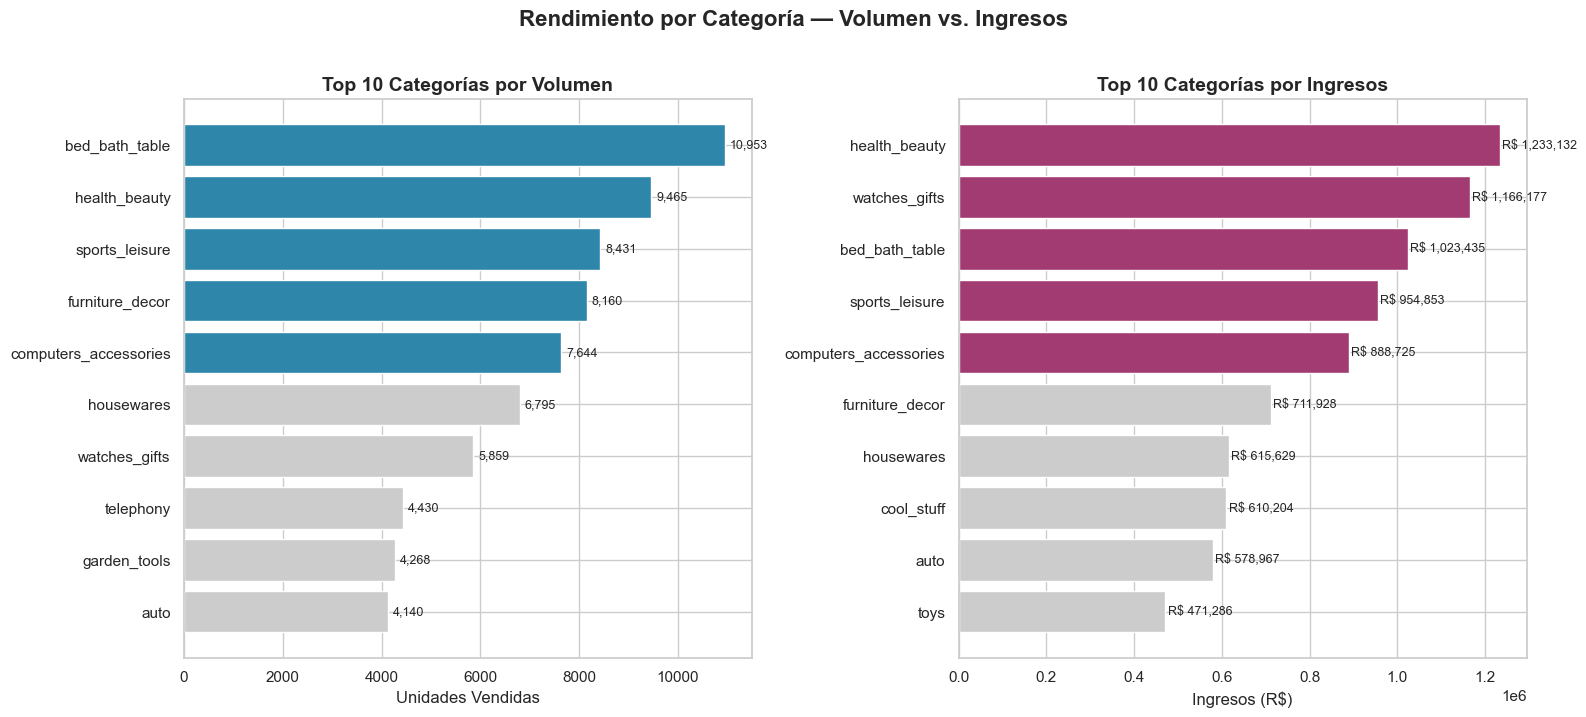

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Gráfico de volumen ---
ax1 = axes[0]
top10_vol = cat_stats.head(10)
bars1 = ax1.barh(top10_vol.index[::-1], top10_vol['units_sold'][::-1], 
                  color=[COLORS['primary'] if i < 5 else '#cccccc' for i in range(9, -1, -1)])
ax1.set_xlabel('Unidades Vendidas')
ax1.set_title('Top 10 Categorías por Volumen', fontsize=14, fontweight='bold')
for bar, val in zip(bars1, top10_vol['units_sold'][::-1]):
    ax1.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, 
             f'{val:,}', va='center', fontsize=9)

# --- Gráfico de ingresos ---
ax2 = axes[1]
top10_rev = cat_stats.sort_values('total_revenue', ascending=False).head(10)
bars2 = ax2.barh(top10_rev.index[::-1], top10_rev['total_revenue'][::-1],
                  color=[COLORS['secondary'] if i < 5 else '#cccccc' for i in range(9, -1, -1)])
ax2.set_xlabel('Ingresos (R$)')
ax2.set_title('Top 10 Categorías por Ingresos', fontsize=14, fontweight='bold')
for bar, val in zip(bars2, top10_rev['total_revenue'][::-1]):
    ax2.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2, 
             f'R$ {val:,.0f}', va='center', fontsize=9)

plt.suptitle('Rendimiento por Categoría — Volumen vs. Ingresos', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/01_top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Top 5 Productos Individuales — por Volumen e Ingresos

In [7]:
# Agregar por producto individual
product_stats = sales.groupby('product_id').agg(
    units_sold=('order_item_id', 'count'),
    total_revenue=('price', 'sum'),
    avg_price=('price', 'mean'),
    category=('category', 'first'),
    num_orders=('order_id', 'nunique')
).sort_values('units_sold', ascending=False)

top5_prod_vol = product_stats.head(5).copy()
top5_prod_rev = product_stats.sort_values('total_revenue', ascending=False).head(5).copy()

# Agregar etiquetas cortas para visualización
top5_prod_vol['label'] = [f'{cat}\n({pid[:8]}...)' 
                           for pid, cat in zip(top5_prod_vol.index, top5_prod_vol['category'])]
top5_prod_rev['label'] = [f'{cat}\n({pid[:8]}...)' 
                           for pid, cat in zip(top5_prod_rev.index, top5_prod_rev['category'])]

print('TOP 5 PRODUCTOS POR VOLUMEN')
print('=' * 80)
print(top5_prod_vol[['category', 'units_sold', 'total_revenue', 'avg_price']].to_string(
    formatters={'total_revenue': 'R$ {:,.0f}'.format, 'avg_price': 'R$ {:,.2f}'.format}
))

print(f'\n\nTOP 5 PRODUCTOS POR INGRESOS')
print('=' * 80)
print(top5_prod_rev[['category', 'total_revenue', 'units_sold', 'avg_price']].to_string(
    formatters={'total_revenue': 'R$ {:,.0f}'.format, 'avg_price': 'R$ {:,.2f}'.format}
))

TOP 5 PRODUCTOS POR VOLUMEN
                                         category  units_sold total_revenue avg_price
product_id                                                                           
aca2eb7d00ea1a7b8ebd4e68314663af  furniture_decor         520     R$ 37,104  R$ 71.35
422879e10f46682990de24d770e7f83d     garden_tools         484     R$ 26,577  R$ 54.91
99a4788cb24856965c36a24e339b6058   bed_bath_table         477     R$ 42,050  R$ 88.15
389d119b48cf3043d311335e499d9c6b     garden_tools         390     R$ 21,337  R$ 54.71
368c6c730842d78016ad823897a372db     garden_tools         388     R$ 21,057  R$ 54.27


TOP 5 PRODUCTOS POR INGRESOS
                                               category total_revenue  units_sold   avg_price
product_id                                                                                   
bb50f2e236e5eea0100680137654686c          health_beauty     R$ 63,560         194   R$ 327.63
6cdd53843498f92890544667809f1595          health_beauty  

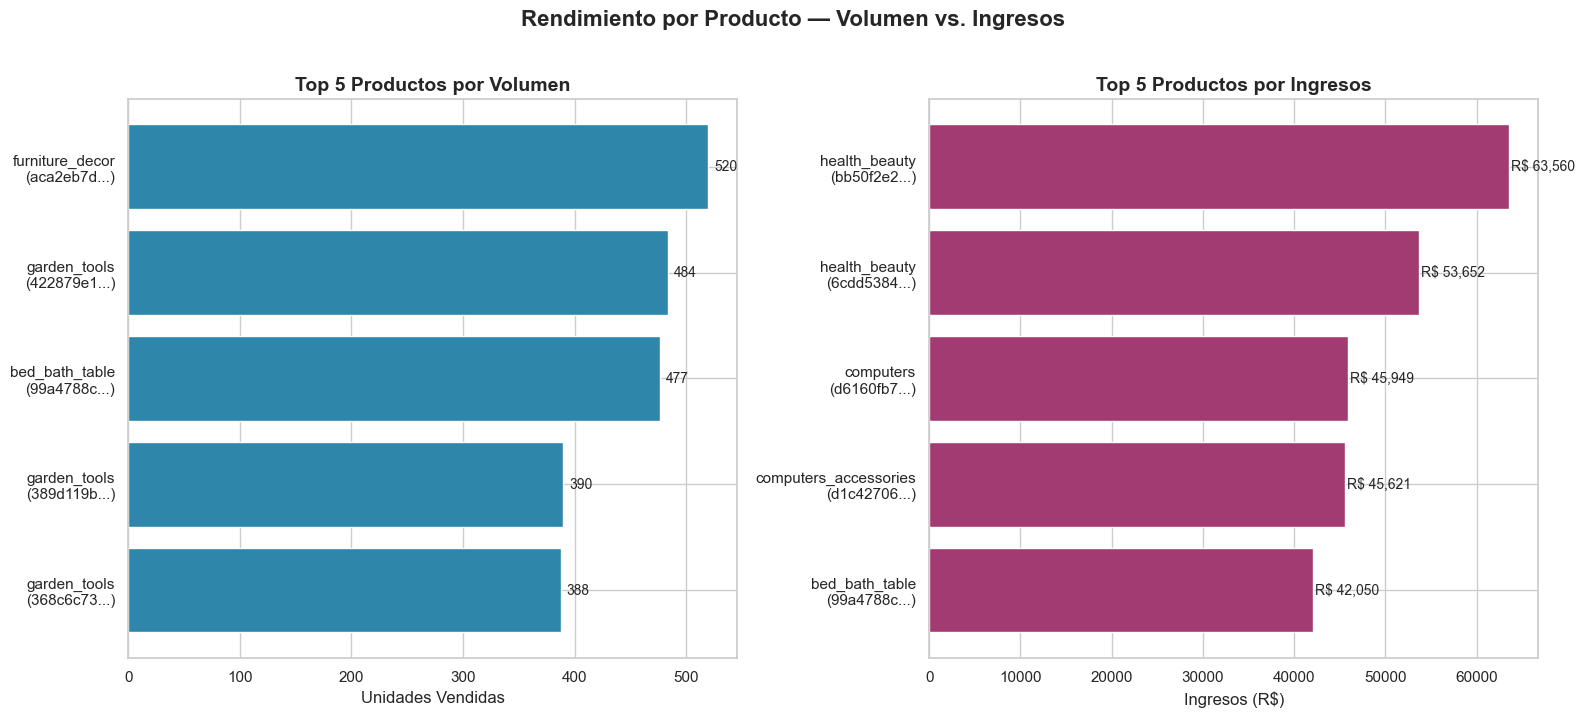

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Top productos por volumen ---
ax1 = axes[0]
bars1 = ax1.barh(top5_prod_vol['label'][::-1], top5_prod_vol['units_sold'][::-1], 
                  color=COLORS['primary'])
ax1.set_xlabel('Unidades Vendidas')
ax1.set_title('Top 5 Productos por Volumen', fontsize=14, fontweight='bold')
for bar, val in zip(bars1, top5_prod_vol['units_sold'][::-1]):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10)

# --- Top productos por ingresos ---
ax2 = axes[1]
bars2 = ax2.barh(top5_prod_rev['label'][::-1], top5_prod_rev['total_revenue'][::-1],
                  color=COLORS['secondary'])
ax2.set_xlabel('Ingresos (R$)')
ax2.set_title('Top 5 Productos por Ingresos', fontsize=14, fontweight='bold')
for bar, val in zip(bars2, top5_prod_rev['total_revenue'][::-1]):
    ax2.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f'R$ {val:,.0f}', va='center', fontsize=10)

plt.suptitle('Rendimiento por Producto — Volumen vs. Ingresos',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/01_top_products.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Insight: Matriz de Volumen vs. Ingresos

Las categorías que se posicionan alto en volumen pero bajo en ingresos (y viceversa) revelan estrategias de negocio distintas.

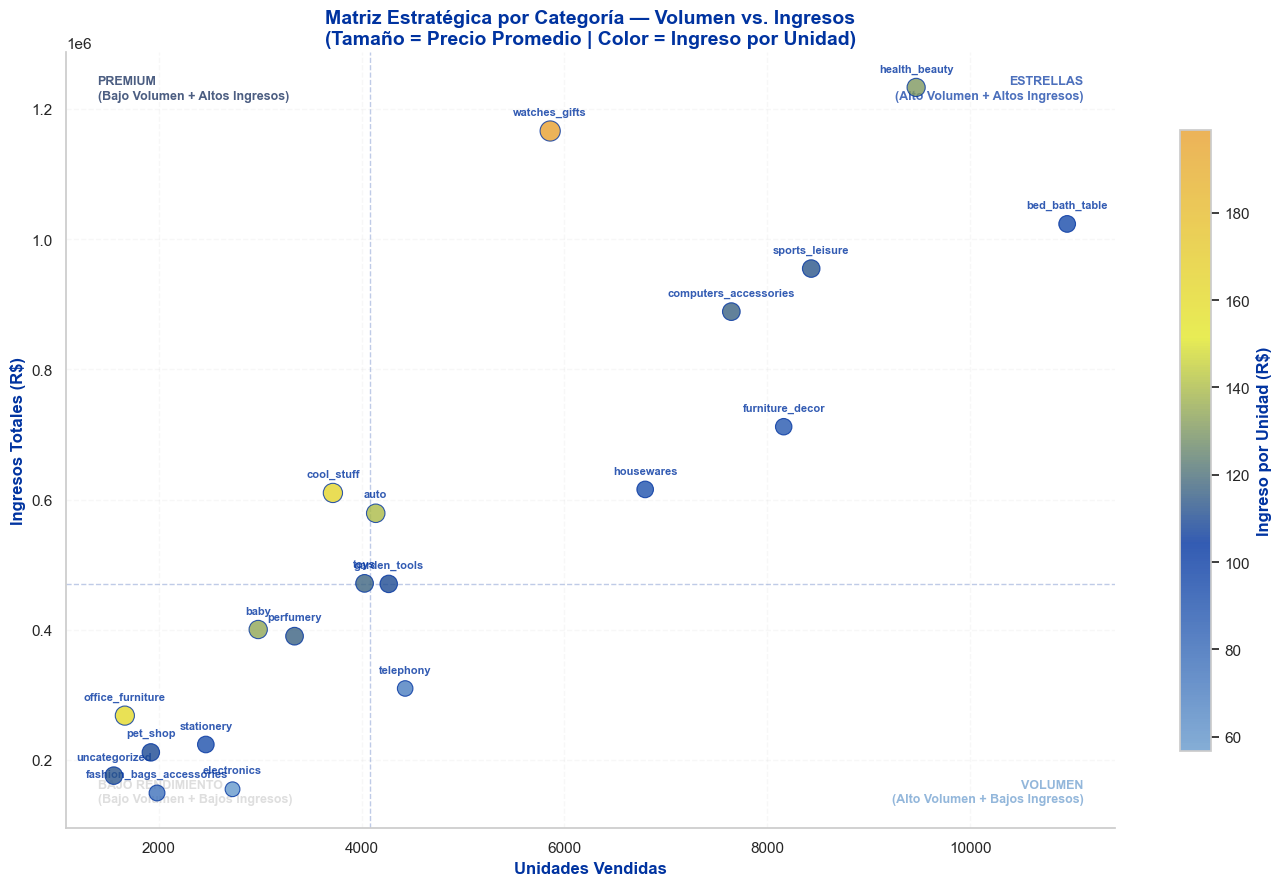

In [9]:
# --- Matriz Estratégica: Volumen vs Ingresos por categoría (top 20) ---
top20 = cat_stats.head(20).copy()

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

BLUE = '#0033a0'

# Mapa de colores personalizado con paleta empresarial
from matplotlib.colors import LinearSegmentedColormap
company_cmap = LinearSegmentedColormap.from_list(
    'company_value', ['#6699cc', '#0033a0', '#e3e82a', '#e8a030']
)

# Escalado raíz cuadrada para tamaños de burbuja balanceados
bubble_sizes = np.sqrt(top20['avg_price']) * 15

scatter = ax.scatter(
    top20['units_sold'], top20['total_revenue'],
    s=bubble_sizes,
    c=top20['revenue_per_unit'],
    cmap=company_cmap, alpha=0.8, edgecolors=BLUE, linewidth=0.8,
    zorder=5
)

for idx, row in top20.iterrows():
    ax.annotate(idx, (row['units_sold'], row['total_revenue']),
                fontsize=8, ha='center', va='bottom', color=BLUE,
                xytext=(0, 10), textcoords='offset points',
                fontweight='bold', alpha=0.8)

# Líneas de cuadrante en percentil 75 (umbrales significativos)
vol_threshold = top20['units_sold'].quantile(0.5)
rev_threshold = top20['total_revenue'].quantile(0.5)
ax.axvline(x=vol_threshold, color=BLUE, linestyle='--', alpha=0.25, linewidth=1)
ax.axhline(y=rev_threshold, color=BLUE, linestyle='--', alpha=0.25, linewidth=1)

# Etiquetas de los 4 cuadrantes
xlim = ax.get_xlim()
ylim = ax.get_ylim()
pad_x = (xlim[1] - xlim[0]) * 0.03
pad_y = (ylim[1] - ylim[0]) * 0.03

ax.text(xlim[1] - pad_x, ylim[1] - pad_y, 'ESTRELLAS\n(Alto Volumen + Altos Ingresos)',
        fontsize=9, ha='right', va='top', color='#0033a0', fontweight='bold', alpha=0.7)
ax.text(xlim[0] + pad_x, ylim[1] - pad_y, 'PREMIUM\n(Bajo Volumen + Altos Ingresos)',
        fontsize=9, ha='left', va='top', color='#001a4d', fontweight='bold', alpha=0.7)
ax.text(xlim[1] - pad_x, ylim[0] + pad_y, 'VOLUMEN\n(Alto Volumen + Bajos Ingresos)',
        fontsize=9, ha='right', va='bottom', color='#6699cc', fontweight='bold', alpha=0.7)
ax.text(xlim[0] + pad_x, ylim[0] + pad_y, 'BAJO RENDIMIENTO\n(Bajo Volumen + Bajos Ingresos)',
        fontsize=9, ha='left', va='bottom', color='#d0d0d0', fontweight='bold', alpha=0.7)

cbar = plt.colorbar(scatter, label='Ingreso por Unidad (R$)', shrink=0.8)
cbar.ax.yaxis.label.set_color(BLUE)
cbar.ax.yaxis.label.set_fontweight('bold')

ax.set_xlabel('Unidades Vendidas', fontsize=12, color=BLUE, fontweight='bold')
ax.set_ylabel('Ingresos Totales (R$)', fontsize=12, color=BLUE, fontweight='bold')
ax.set_title('Matriz Estratégica por Categoría — Volumen vs. Ingresos\n'
             '(Tamaño = Precio Promedio | Color = Ingreso por Unidad)',
             fontsize=14, fontweight='bold', color=BLUE)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.15, linestyle='--')
plt.tight_layout()
plt.savefig('../outputs/01_category_matrix.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


---
## 7. Concentración de Ingresos — Análisis de Pareto

La clásica pregunta del 80/20: **¿cuántas categorías se necesitan para generar el 80% de los ingresos totales?** Esto revela qué tan concentrado está el negocio y si la estrategia de crecimiento debe enfocarse en profundizar el top o ampliar la cola larga.

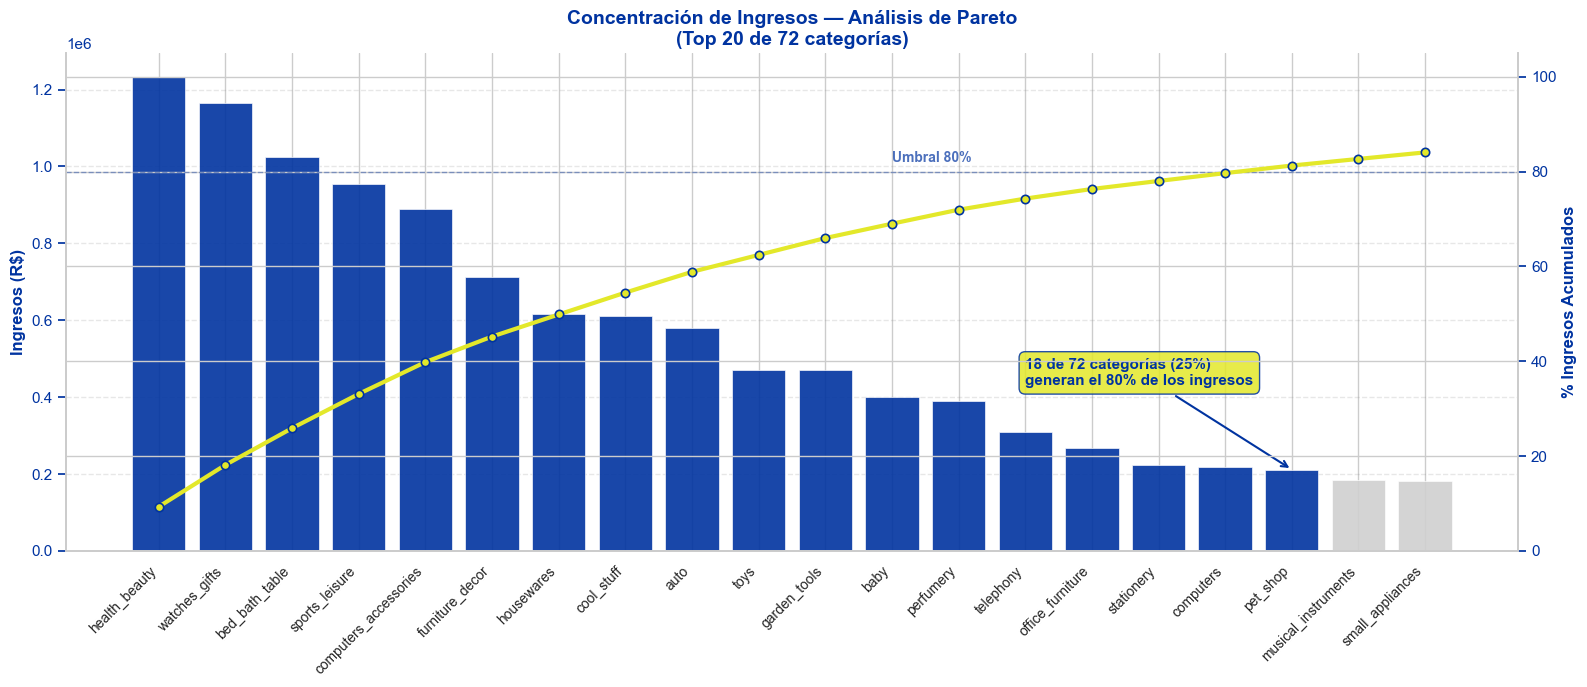


RESUMEN DE CONCENTRACIÓN
Total categorías: 72
Categorías para alcanzar 80% de ingresos: 18 (25.0% del catálogo)
Top 5 categorías concentran: 39.8%
Top 10 categorías concentran: 62.4%


In [10]:
# --- Análisis de Pareto / Concentración ---
cat_revenue_sorted = cat_stats.sort_values('total_revenue', ascending=False).copy()
cat_revenue_sorted['cumulative_revenue'] = cat_revenue_sorted['total_revenue'].cumsum()
cat_revenue_sorted['cumulative_pct'] = (cat_revenue_sorted['cumulative_revenue'] / 
                                         cat_revenue_sorted['total_revenue'].sum() * 100)
cat_revenue_sorted['rank'] = range(1, len(cat_revenue_sorted) + 1)

# Encontrar el umbral del 80%
n_cats_80 = (cat_revenue_sorted['cumulative_pct'] <= 80).sum() + 1
total_cats = len(cat_revenue_sorted)
pct_cats_80 = n_cats_80 / total_cats * 100

fig, ax1 = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')

# Colores empresariales
BLUE = '#0033a0'
YELLOW = '#e3e82a'
GREY_OUT = '#d0d0d0'

# Gráfico de barras — contribución individual de ingresos (top 20 para legibilidad)
top_n = 20
plot_data = cat_revenue_sorted.head(top_n)
bars = ax1.bar(range(top_n), plot_data['total_revenue'], 
               color=[BLUE if i < n_cats_80 else GREY_OUT for i in range(top_n)],
               alpha=0.9, edgecolor='white', linewidth=0.5)
ax1.set_ylabel('Ingresos (R$)', fontsize=12, color=BLUE, fontweight='bold')
ax1.set_xticks(range(top_n))
ax1.set_xticklabels(plot_data.index, rotation=45, ha='right', fontsize=10)
ax1.yaxis.grid(True, alpha=0.2, linestyle='--', color='#888888')
ax1.set_axisbelow(True)
ax1.tick_params(axis='y', colors=BLUE)

# Línea acumulada en eje secundario — amarillo con borde oscuro para legibilidad
ax2 = ax1.twinx()
ax2.plot(range(top_n), plot_data['cumulative_pct'], 
         color=YELLOW, marker='o', markersize=6, linewidth=3,
         markeredgecolor=BLUE, markeredgewidth=1.2, zorder=5)
ax2.set_ylabel('% Ingresos Acumulados', fontsize=12, color=BLUE, fontweight='bold')
ax2.set_ylim(0, 105)
ax2.tick_params(axis='y', colors=BLUE)

# Línea de umbral 80% + etiqueta desplazada a la derecha para no tapar las barras altas
ax2.axhline(y=80, color=BLUE, linestyle='--', alpha=0.4, linewidth=1)
ax2.text(top_n * 0.55, 82, 'Umbral 80%', fontsize=10, color=BLUE, fontweight='bold', alpha=0.7)

# Annotation — inside the chart area, below the cutoff point
cutoff_idx = min(n_cats_80 - 1, top_n - 1)
ax1.annotate(
    f'{n_cats_80} de {total_cats} categorías ({pct_cats_80:.0f}%)\ngeneran el 80% de los ingresos',
    xy=(cutoff_idx, plot_data.iloc[cutoff_idx]['total_revenue']),
    xytext=(cutoff_idx - 4, plot_data.iloc[0]['total_revenue'] * 0.35),
    fontsize=11, fontweight='bold', color=BLUE,
    arrowprops=dict(arrowstyle='->', color=BLUE, lw=1.5),
    bbox=dict(boxstyle='round,pad=0.4', facecolor=YELLOW, edgecolor=BLUE, alpha=0.85)
)

ax1.set_title(f'Concentración de Ingresos — Análisis de Pareto\n(Top {top_n} de {total_cats} categorías)',
              fontsize=14, fontweight='bold', color=BLUE)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/01_pareto_revenue.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f'\nRESUMEN DE CONCENTRACIÓN')
print(f'{"=" * 50}')
print(f'Total categorías: {total_cats}')
print(f'Categorías para alcanzar 80% de ingresos: {n_cats_80} ({pct_cats_80:.1f}% del catálogo)')
print(f'Top 5 categorías concentran: {cat_revenue_sorted.head(5)["cumulative_pct"].iloc[-1]:.1f}%')
print(f'Top 10 categorías concentran: {cat_revenue_sorted.head(10)["cumulative_pct"].iloc[-1]:.1f}%')


---
## 8. Tendencias Temporales — Evolución Mensual de Ventas

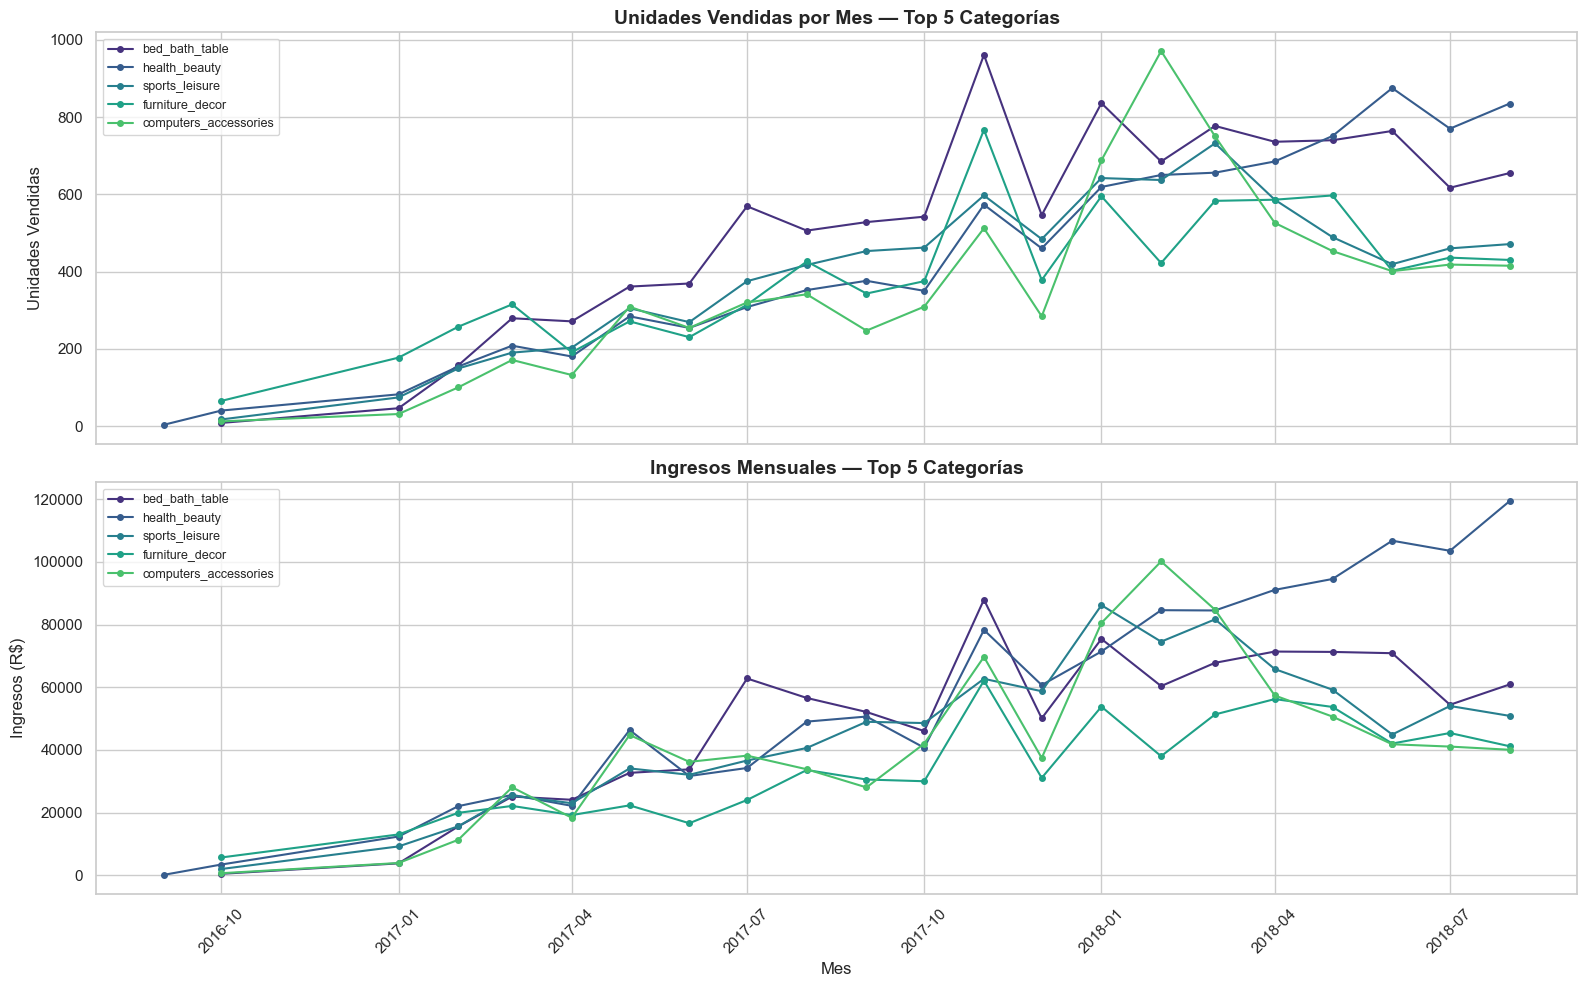

In [11]:
# Tendencia mensual para las top 5 categorías por volumen
top5_cats = cat_stats.head(5).index.tolist()
monthly_sales = (
    sales[sales['category'].isin(top5_cats)]
    .groupby([sales[sales['category'].isin(top5_cats)]['order_purchase_timestamp'].dt.to_period('M'), 'category'])
    .agg(units=('order_item_id', 'count'), revenue=('price', 'sum'))
    .reset_index()
)
monthly_sales['month'] = monthly_sales['order_purchase_timestamp'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

for cat in top5_cats:
    cat_data = monthly_sales[monthly_sales['category'] == cat]
    axes[0].plot(cat_data['month'], cat_data['units'], marker='o', markersize=4, label=cat)
    axes[1].plot(cat_data['month'], cat_data['revenue'], marker='o', markersize=4, label=cat)

axes[0].set_title('Unidades Vendidas por Mes — Top 5 Categorías', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Unidades Vendidas')
axes[0].legend(loc='upper left', fontsize=9)

axes[1].set_title('Ingresos Mensuales — Top 5 Categorías', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Ingresos (R$)')
axes[1].set_xlabel('Mes')
axes[1].legend(loc='upper left', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/01_monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Hallazgos y Resumen

### Top 5 Categorías por Volumen
| Posición | Categoría | Unidades Vendidas |
|------|----------|------------|
| 1 | Cama, Baño y Mesa | ~10,950 |
| 2 | Salud y Belleza | ~9,465 |
| 3 | Deportes y Ocio | ~8,430 |
| 4 | Muebles y Decoración | ~8,160 |
| 5 | Computadores y Accesorios | ~7,640 |

### Top 5 Categorías por Ingresos
| Posición | Categoría | Ingresos (R$) |
|------|----------|-------------|
| 1 | Salud y Belleza | ~R$ 1,233K |
| 2 | Relojes y Regalos | ~R$ 1,166K |
| 3 | Cama, Baño y Mesa | ~R$ 1,023K |
| 4 | Deportes y Ocio | ~R$ 955K |
| 5 | Computadores y Accesorios | ~R$ 889K |

### Conclusiones

1. **Salud y Belleza es el top en ingresos** a pesar de ser #2 en volumen — su ticket promedio más alto lo convierte en la categoría más valiosa en general.

2. **Relojes y Regalos entra al top 5 por ingresos** (no presente en el top 5 de volumen) — es una **categoría premium**: menos ventas, mayor precio unitario. Representa una oportunidad de venta cruzada y upselling.

3. **Cama, Baño y Mesa lidera en volumen pero ocupa el #3 en ingresos** — una categoría de alta frecuencia y ticket bajo. Ideal para estrategias de adquisición y engagement de clientes.

4. **Alta concentración de ingresos** — el análisis de Pareto revela que una pequeña fracción de categorías genera la mayoría de los ingresos. Esta concentración representa tanto un riesgo (dependencia de pocas categorías) como una oportunidad (la inversión enfocada genera retornos desproporcionados).

5. **Tendencia de crecimiento clara** en todas las categorías top durante 2017-2018.